<a href="https://colab.research.google.com/github/Alex-Sun-316/Bus_Event_-Simulator/blob/main/Bus_Event_Simulator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from collections import deque
import random
import heapq
import itertools
import numpy as np
import matplotlib.pyplot as plt


def fmt(x):
    return None if x is None else "{:.2f}".format(x)


class Event:
    def __init__(self, method, delay=0, args=None, kwargs=None):
        self.method = method
        self.delay = delay
        self.args = args or []
        self.kwargs = kwargs or {}
        self.time = None

    def __call__(self, time):
        return self.method(*self.args, time=time, **self.kwargs)

    def __lt__(self, other):
        return self.time < other.time

    def __repr__(self):
        return "@{}: {} {} {} {} dt={:.2f}".format(
            fmt(self.time),
            self.method.__self__.__class__.__name__,
            self.method.__name__,
            self.args,
            self.kwargs,
            self.delay
        )


class EventSimulator:
    def __init__(self, trace=False):
        self.events = []
        self.time = 0
        self.trace = trace

    def add_event(self, event):
        event.time = self.time + event.delay
        heapq.heappush(self.events, event)

    def step(self):
        if len(self.events) > 0:
            event = heapq.heappop(self.events)
            self.time = event.time
            new_events = event(self.time) or []

            for e in new_events:
                self.add_event(e)

            if self.trace:
                print("Processing:", event)
                print("New events:", new_events)
                print("Future events:", self.events)

    def steps(self, number=None):
        num_done = 0
        while len(self.events) > 0:
            self.step()
            num_done += 1
            if number is not None and num_done == number:
                break


class Person:
    def __init__(self, start_time, source, destination, have_arrived, person_id=None):
        self.start_time = start_time
        self.bus_time = None
        self.end_time = None
        self.source = source
        self.destination = destination
        self.have_arrived = have_arrived
        self.id = person_id

    def arrived(self, time=None):
        self.end_time = time
        self.have_arrived.append(self)
        return []

    def start_bus(self, time=None):
        self.bus_time = time

    @property
    def elapsed_time(self):
        return None if self.end_time is None else self.end_time - self.start_time

    @property
    def travel_time(self):
        return None if self.end_time is None else self.end_time - self.bus_time

    @property
    def wait_time(self):
        return None if self.end_time is None else self.bus_time - self.start_time

    def __repr__(self):
        return f"Person #{self.id}: source={self.source}, dest={self.destination}"


class Source:
    def __init__(self, rate=1.0, queue_ring=None, number=None, have_arrived=None):
        self.rate = rate
        self.queue_ring = queue_ring
        self.num_stops = len(queue_ring)
        self.number = number
        self.have_arrived = have_arrived
        self.person_id = 0

    def start(self, time=None):
        if self.number == 0:
            return []

        self.person_id += 1
        source, destination = random.sample(range(self.num_stops), 2)

        person = Person(
            start_time=time,
            source=source,
            destination=destination,
            have_arrived=self.have_arrived,
            person_id=self.person_id
        )

        queue = self.queue_ring[source]
        enter_event = Event(queue.enter, args=[person])

        self.number = None if self.number is None else self.number - 1
        dt = np.random.gamma(1, 1 / self.rate)
        next_person_event = Event(self.start, delay=dt)

        return [enter_event, next_person_event]


class Queue:
    def __init__(self):
        self.people = deque()

    def enter(self, person, time=None):
        self.people.append(person)

    def pop_next(self):
        return self.people.popleft() if self.people else None

    def __len__(self):
        return len(self.people)

    def __repr__(self):
        return f"Queue(size={len(self.people)})"


class Bus:
    def __init__(self, queue_ring, max_capacity, geton_time, nextstop_time, bus_id=None):
        self.queue_ring = queue_ring
        self.max_capacity = max_capacity
        self.geton_time = geton_time
        self.nextstop_time = nextstop_time
        self.id = bus_id
        self._stop = None
        self._onboard = []

    @property
    def stop(self):
        return self._stop

    @property
    def onboard(self):
        return self._onboard

    @property
    def occupancy(self):
        return len(self._onboard)

    def _t_getonoff(self):
        return float(np.random.gamma(2, self.geton_time / 2))

    def _t_nextstop(self):
        return float(np.random.gamma(10, self.nextstop_time / 10))

    def _num_stops(self):
        return len(self.queue_ring)

    def _has_dropoffs(self, stop_idx):
        return any(p.destination == stop_idx for p in self._onboard)

    def arrive(self, stop_idx, time=None):
        self._stop = stop_idx

        if self._has_dropoffs(stop_idx):
            return [Event(self._off_one, delay=self._t_getonoff(), args=[stop_idx])]

        return self._start_board_or_depart(stop_idx)

    def _off_one(self, stop_idx, time=None):
        off_i = None
        for i, person in enumerate(self._onboard):
            if person.destination == stop_idx:
                off_i = i
                break

        if off_i is not None:
            person = self._onboard.pop(off_i)
            person.arrived(time=time)

        if self._has_dropoffs(stop_idx):
            return [Event(self._off_one, delay=self._t_getonoff(), args=[stop_idx])]

        return self._start_board_or_depart(stop_idx)

    def _start_board_or_depart(self, stop_idx):
        q = self.queue_ring[stop_idx]

        if self.occupancy < self.max_capacity and len(q) > 0:
            return [Event(self._on_one, delay=self._t_getonoff(), args=[stop_idx])]

        return [Event(self._depart, delay=self._t_nextstop(), args=[stop_idx])]

    def _on_one(self, stop_idx, time=None):
        q = self.queue_ring[stop_idx]

        if self.occupancy < self.max_capacity and len(q) > 0:
            person = q.pop_next()
            if person is not None:
                person.start_bus(time=time)
                self._onboard.append(person)

        if self.occupancy < self.max_capacity and len(q) > 0:
            return [Event(self._on_one, delay=self._t_getonoff(), args=[stop_idx])]

        return [Event(self._depart, delay=self._t_nextstop(), args=[stop_idx])]

    def _depart(self, stop_idx, time=None):
        next_stop = (stop_idx + 1) % self._num_stops()
        return [Event(self.arrive, args=[next_stop])]

    def __repr__(self):
        return f"Bus #{self.id}: stop={self.stop}, occupancy={self.occupancy}"


def bus_distance(ix, iy, num_stops=20):
    if ix is None or iy is None:
        return None
    d1 = (ix - iy + num_stops) % num_stops
    d2 = (iy - ix + num_stops) % num_stops
    return min(d1, d2)


class Simulation:
    def __init__(
        self,
        num_stops=20,
        num_buses=1,
        bus_nextstop_time=1,
        bus_geton_time=0.1,
        bus_max_capacity=50,
        person_rate=2,
        number_of_people=None,
        trace=False
    ):
        self.num_stops = num_stops
        self.num_buses = num_buses
        self.bus_max_capacity = bus_max_capacity
        self.initial_stops = list(
            np.mod(
                np.arange(0, self.num_buses) * max(1, num_stops // num_buses),
                num_stops
            )
        )

        self.bus_nextstop_time = bus_nextstop_time
        self.bus_geton_time = bus_geton_time
        self.person_rate = person_rate

        self.simulator = EventSimulator(trace=trace)
        self.queue_ring = [Queue() for _ in range(num_stops)]

        self.have_arrived = []
        self.source = Source(
            rate=person_rate,
            queue_ring=self.queue_ring,
            number=number_of_people,
            have_arrived=self.have_arrived
        )

        self.buses = [
            Bus(
                queue_ring=self.queue_ring,
                max_capacity=bus_max_capacity,
                geton_time=bus_geton_time,
                nextstop_time=bus_nextstop_time,
                bus_id=i + 1
            )
            for i in range(num_buses)
        ]

        self.positions = [[] for _ in range(num_buses)]
        self.occupancies = [[] for _ in range(num_buses)]

    def start(self):
        self.simulator.add_event(Event(self.source.start))
        for i, bus in enumerate(self.buses):
            self.simulator.add_event(Event(bus.arrive, args=[self.initial_stops[i]]))

    def step(self):
        self.simulator.step()
        for bus_idx in range(self.num_buses):
            self.positions[bus_idx].append(self.buses[bus_idx].stop)
            self.occupancies[bus_idx].append(self.buses[bus_idx].occupancy)

    def run(self, steps=1000):
        self.start()
        for _ in range(steps):
            if len(self.simulator.events) == 0:
                break
            self.step()

    def plot(self):
        for bus_idx in range(self.num_buses):
            plt.plot(self.positions[bus_idx])
        plt.title("Positions")
        plt.show()

        for bus_idx in range(self.num_buses):
            plt.plot(self.occupancies[bus_idx])
        plt.title("Occupancies")
        plt.show()

        plt.hist([p.wait_time for p in self.have_arrived if p.wait_time is not None])
        plt.title("Wait Time")
        plt.show()

        plt.hist([p.travel_time for p in self.have_arrived if p.travel_time is not None])
        plt.title("Travel Time")
        plt.show()

        plt.hist([p.elapsed_time for p in self.have_arrived if p.elapsed_time is not None])
        plt.title("Total Time")
        plt.show()

        if self.num_buses > 1:
            for i, j in itertools.combinations(range(self.num_buses), 2):
                ds = [
                    bus_distance(pi, pj, num_stops=self.num_stops)
                    for pi, pj in zip(self.positions[i], self.positions[j])
                ]
                plt.plot(ds)
            plt.title("Bus Distances")
            plt.show()

    def status(self):
        for stop_idx, queue in enumerate(self.queue_ring):
            buses_here = [bus for bus in self.buses if bus.stop == stop_idx]
            print(f"Stop {stop_idx}")
            print(f"  Queue: {list(queue.people)}")
            print(f"  Buses: {buses_here}")


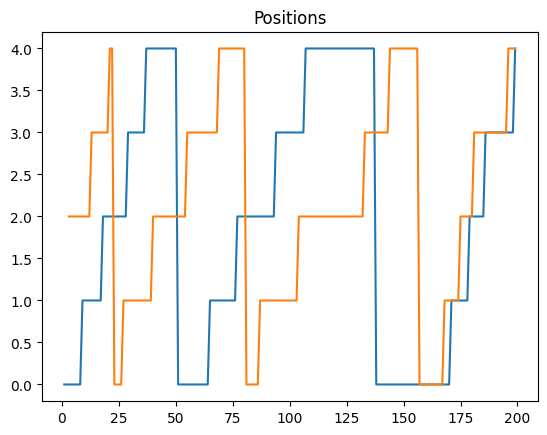

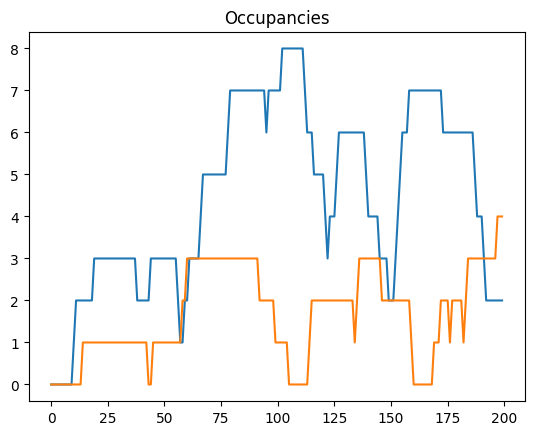

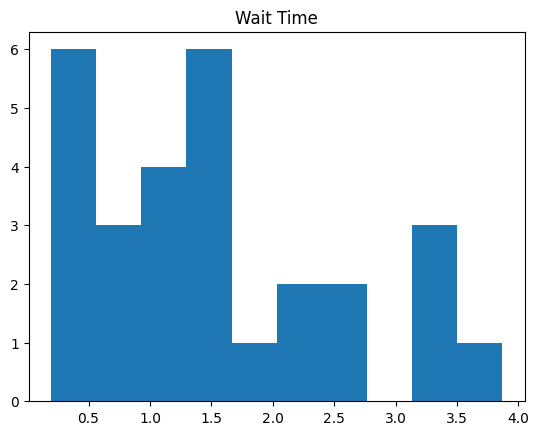

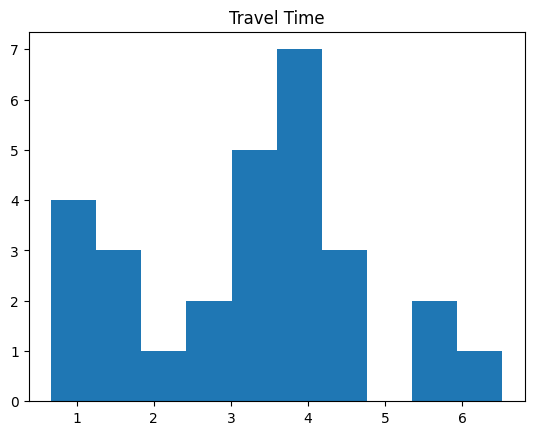

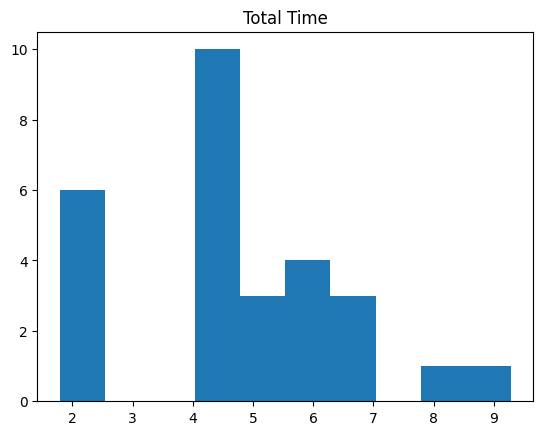

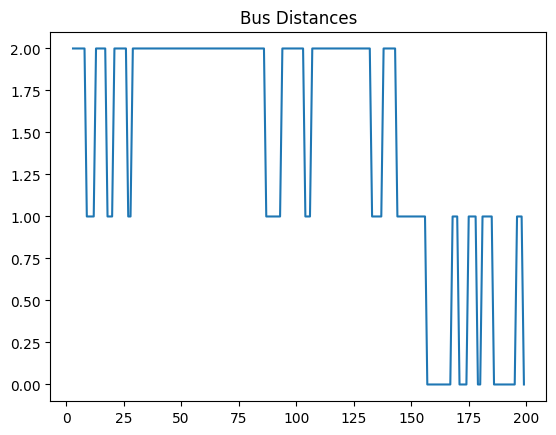

Stop 0
  Queue: [Person #35: source=0, dest=1, Person #36: source=0, dest=3, Person #37: source=0, dest=1]
  Buses: []
Stop 1
  Queue: []
  Buses: []
Stop 2
  Queue: []
  Buses: []
Stop 3
  Queue: []
  Buses: []
Stop 4
  Queue: []
  Buses: [Bus #1: stop=4, occupancy=2, Bus #2: stop=4, occupancy=4]


In [ ]:
if __name__ == "__main__":
    sim = Simulation(
        num_stops=5,
        num_buses=2,
        person_rate=2,
        trace=False
    )
    sim.run(steps=200)
    sim.plot()
    sim.status()